In [7]:
# Talelr 5 - Reducción de Dimensiones y Clustering con Spotify

In [8]:
# BLOQUE 1 : CONFIGURACIÓN Y CARGA DE DATOS

In [9]:
# Se importan las librerías necesarias
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import pandas as pd

In [10]:
# Se carga Dataset Spotify
import pandas as pd

df = pd.read_csv(r"C:\Users\misae\Downloads\spotifydataset.csv")

print("Dimensiones:", df.shape)
display(df.head())

Dimensiones: (1000, 23)


,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [11]:
# BLOQUE 2 : LIMPIEZA Y PREPARACIÓN 

In [12]:
# Analisis exploratorio de datos
import pandas as pd
data = pd.read_csv(r"C:\Users\misae\Downloads\spotifydataset.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   artist_name        1000 non-null   str    
 2   genres             837 non-null    str    
 3   followers          1000 non-null   int64  
 4   artist_popularity  1000 non-null   int64  
 5   artist_url         1000 non-null   str    
 6   track_name         1000 non-null   str    
 7   album_name         1000 non-null   str    
 8   release_date       1000 non-null   str    
 9   duration_ms        1000 non-null   int64  
 10  explicit           1000 non-null   bool   
 11  track_popularity   1000 non-null   int64  
 12  danceability       1000 non-null   float64
 13  energy             1000 non-null   float64
 14  key                1000 non-null   int64  
 15  loudness           1000 non-null   float64
 16  mode               1000 non-null   i

In [13]:
# Selección de varibales auditivas 
columnas_audio = [
    "track_popularity",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

df_audio = df[columnas_audio].copy()

display(df_audio.head())

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [14]:
# Verificación de valores núlos 
print("Valores nulos:")
print(df_audio.isnull().sum())

Valores nulos:
track_popularity    0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64


In [15]:
# Estandarización de datos
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_audio)

print("Datos estandarizados.")

Datos estandarizados.


In [16]:
# BLOQUE 3: REDUCCIÓN DE DIMENSIONALIDAD (PCA)

In [17]:
# Aplicamos PCA para reducir a 2D y visualizar datos 
pca = PCA(2)

X_pca = pca.fit_transform(X_scaled)


In [18]:
X_pca.shape

(1000, 2)

In [19]:
df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

display(df_pca.head())

,PC1,PC2
0,0.063185,0.129111
1,0.609885,1.542816
2,-1.725773,1.120047
3,1.178713,-0.074323
4,1.060287,0.941007


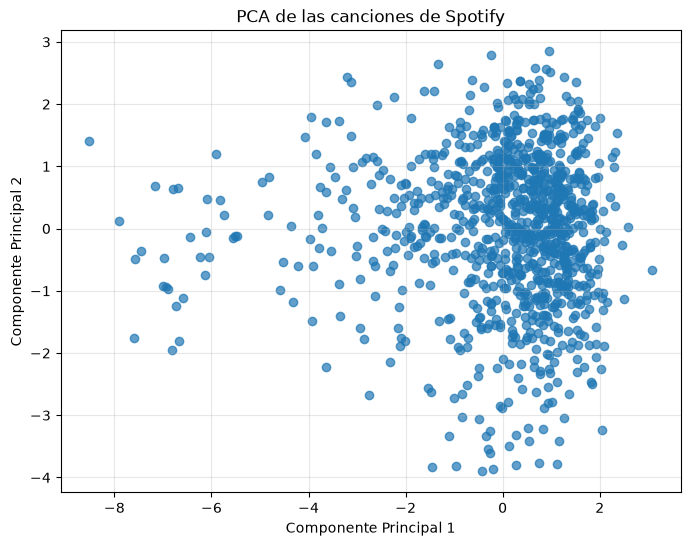

In [20]:
# Visualización usando PCA 
plt.figure(figsize=(8, 6))

plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    alpha=0.7
)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("PCA de las canciones de Spotify")

plt.grid(alpha=0.3)
plt.show()

In [21]:
pca.explained_variance_ratio_

array([0.24909434, 0.12774645])

In [22]:
pca.components_

array([[ 0.17180794,  0.25628222,  0.47744657,  0.03246189,  0.50056181,
        -0.05682778,  0.09593333, -0.4248627 , -0.3800992 ,  0.13580361,
         0.25015896,  0.08241293],
       [ 0.2692642 ,  0.52152962, -0.28522051,  0.11839771, -0.11486544,
        -0.18444993,  0.07814899,  0.26237238, -0.20575325, -0.30985598,
         0.39409065, -0.37989464]])

In [23]:
# BLOQUE 4 : MODELADO K-MEANS

In [24]:

inercia = []
silhouette = []

for k in range(2, 11):
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inercia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

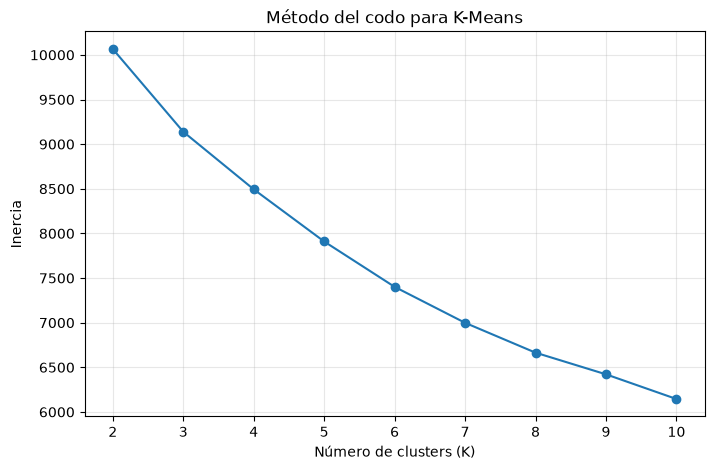

In [25]:
# Usamos metodo del codo para encontrar el número ideal de (clústers)
plt.figure(figsize=(8, 5))

plt.plot( range(2, 11), inercia, marker="o")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo para K-Means")

plt.grid(alpha=0.3)
plt.show()

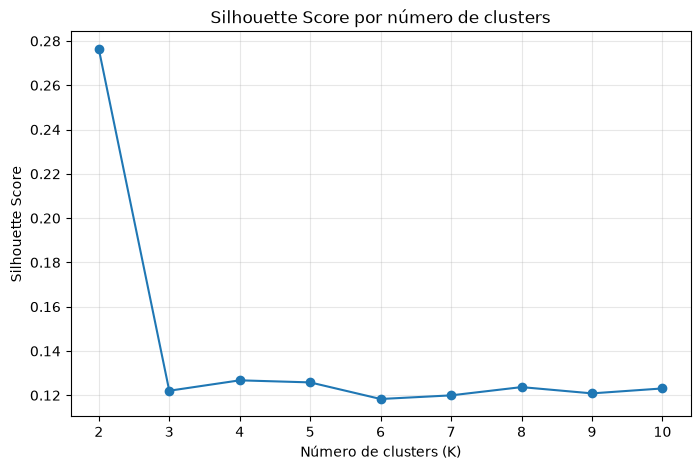

In [26]:
# Debido a que el metodo de codo dío una curva constante no muestra un codo marcado, se usa silhouette score para evidenciar cual agrupa mejor 

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11),silhouette,marker="o")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por número de clusters")

plt.grid(alpha=0.3)
plt.show()

In [27]:
# Identificamos que en 2 alcanza 0,27 aproximadamente por lo que en este número de clusters teniendo en cuenta que el metodo del codo no arrojo un resultado notorio.

In [28]:
# Con este resultado ejecutamos con K= 2 ya que con este los datos se separan de una manera mas definida 
# K- means
kmeans = KMeans(n_clusters=2,random_state=42,n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df_pca["Cluster"] = clusters

print(df_pca["Cluster"].value_counts().sort_index())

Cluster
0    848
1    152
Name: count, dtype: int64


In [29]:
# BLOQUE 5 : VISUALIZACIÓN Y ANÁLISIS 
#Genera visualizaciones que permitan interpretar qué significa cada grupo.

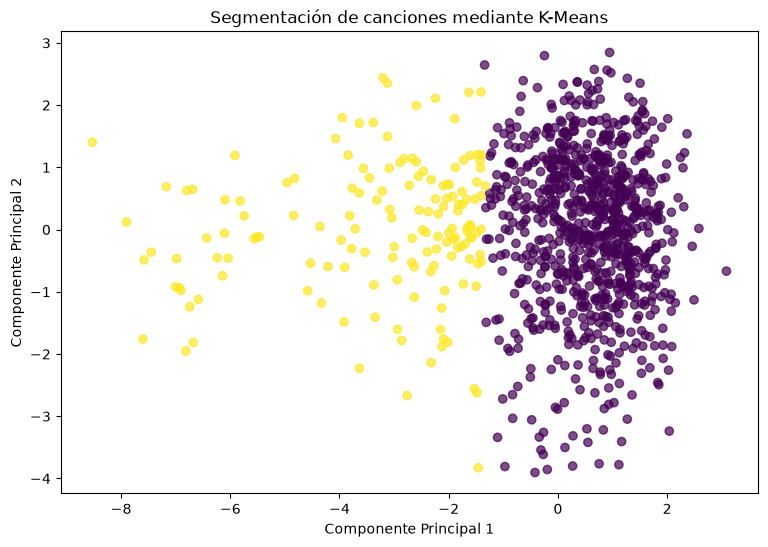

In [30]:
plt.figure(figsize=(9, 6))

plt.scatter(df_pca["PC1"],df_pca["PC2"],c=df_pca["Cluster"],cmap="viridis", alpha=0.7)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Segmentación de canciones mediante K-Means")

plt.show()

In [31]:
# Interpretación 
df_audio["Cluster"] = clusters

In [32]:

perfil_clusters = df_audio.groupby("Cluster").mean()

display(perfil_clusters)

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,,,,
0,61.746462,0.636913,0.719192,5.218160,-5.901133,0.597877,0.097942,0.187645,0.024596,0.198798,0.549701,123.092988
1,46.500000,0.469263,0.333469,5.381579,-14.185605,0.697368,0.054914,0.702085,0.354229,0.133090,0.332203,116.846013


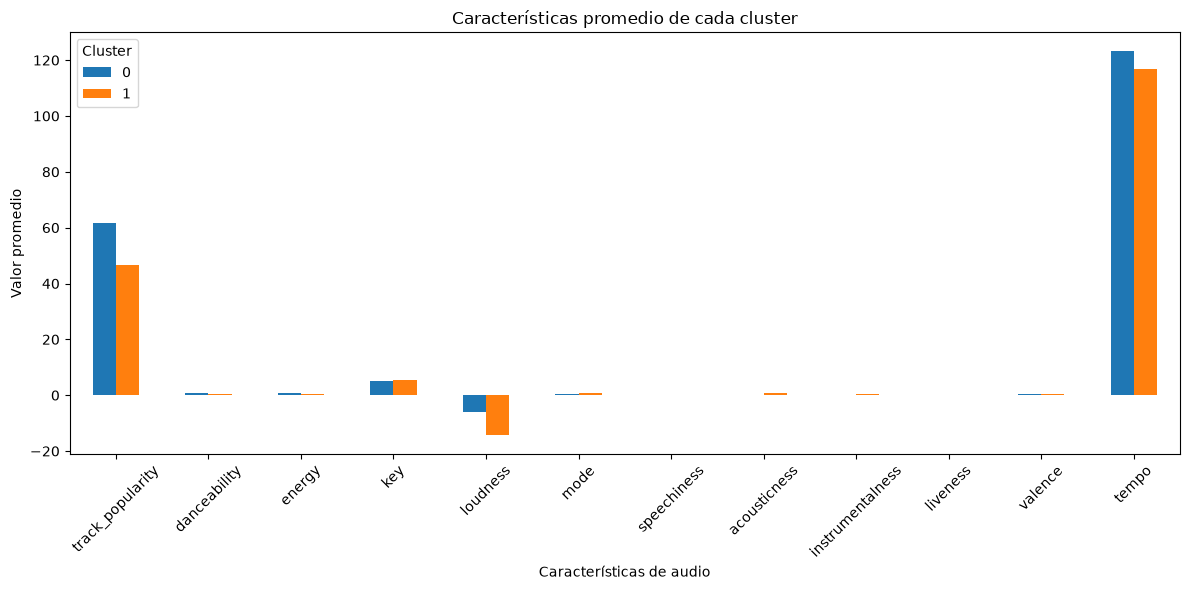

In [35]:
# Grafica con datos originales
perfil_clusters.T.plot(kind="bar",figsize=(12, 6))

plt.title("Características promedio de cada cluster")
plt.xlabel("Características de audio")
plt.ylabel("Valor promedio")
plt.xticks(rotation=45)

plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

In [36]:
df_scaled = pd.DataFrame(
    X_scaled,
    columns=columnas_audio
)

df_scaled["Cluster"] = df_audio["Cluster"].values

In [37]:
perfil_clusters_scaled = df_scaled.groupby("Cluster").mean()

display(perfil_clusters_scaled)

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,,,,
0,0.097075,0.152443,0.282603,-0.006877,0.281243,-0.031049,0.072350,-0.270804,-0.222331,0.068699,0.142022,0.033864
1,-0.541574,-0.850471,-1.576628,0.038367,-1.569042,0.173218,-0.403639,1.510801,1.240371,-0.383267,-0.792331,-0.188927


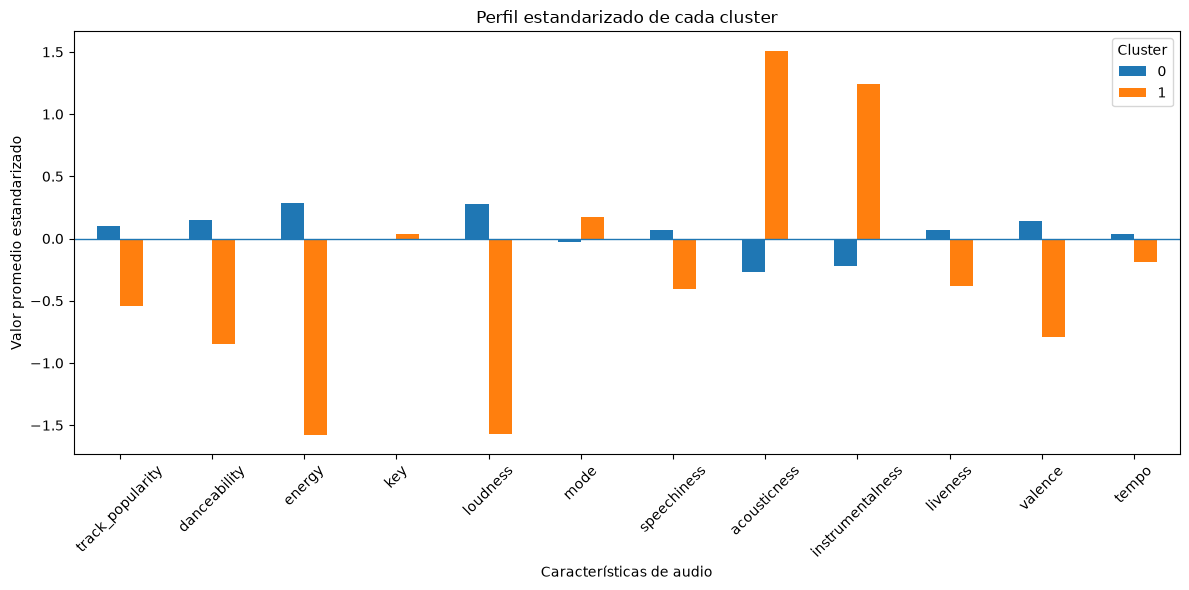

In [ ]:
# Valores estandarizados
perfil_clusters_scaled.T.plot(  kind="bar", figsize=(12, 6))

plt.title("Perfil estandarizado de cada cluster")
plt.xlabel("Características de audio")
plt.ylabel("Valor promedio estandarizado")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:
# Conclusiones
# 1. Por medio del metodo del codo no se logro identificar un punto marcado donde cambia la curva, por ende se usa Silhouette Score para determinar el número de clusters que se debe usar. 
# 2. Los componentes obtenidos mediante PCA cuentan con un 37.68% de la variabilidad total de los datos, por lo que lo consideramos como relativamnete bajo, teniendo en cuenta que buscamos al menos un 80 % de la variancia total, sin embargo, la reducción a dos componentes permite la visualización gráfica de los clusters. 
# 3. La segmentación de las canciones por características de audio y el indice de popularidad pueden contribuir a la recomendación de canciones y playlist, determinando los cluster según las preferencias y características como la energía, tempo y valencia. 
# 4. El analisis permite identificar que el cluster 0, presenta mayores niveles de pupularidad, energia y valence, y el cluster 1 mayores niveles de acousticness e instrumentalness, logrado identificar 2 perfiles de canciones.
# 5. Encontramos un grupo con canciones populares y energetícas y otro con características instrumentales y acusticas.